In [122]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Metadata

In [123]:
proj_root = os.environ['PYTHONPATH']
proj_root

'C:\\Users\\aseva\\Desktop\\MyEDU\\OTUS\\ML_Adv\\OTUS_ML_Adv_GradProj_SaintSanych_v1'

## preproc params

In [124]:
# здесь мы определяем критерии перегрузки сети
thres_fld = 'n_flows'
thres_factor = 2.5

# Соберем целевой TS-датасет (пока двумерный)

## сперва посмотрим на данные

In [125]:
flds_selection = [
    'id_time', 
    'n_flows', 'n_packets', 'n_bytes',
    'average_n_dest_ip', 'std_n_dest_ip',
    'average_n_dest_ports', 'std_n_dest_ports',
    'average_n_dest_asn', 'std_n_dest_asn',
    'tcp_udp_ratio_packets', 'dir_ratio_packets',
    'avg_duration', 'avg_ttl'
]

In [126]:
pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', '0.csv'))[flds_selection]

,id_time,n_flows,n_packets,n_bytes,average_n_dest_ip,std_n_dest_ip,average_n_dest_ports,std_n_dest_ports,average_n_dest_asn,std_n_dest_asn,tcp_udp_ratio_packets,dir_ratio_packets,avg_duration,avg_ttl
0,0,17967588,2009822494,1937481519695,23.96,96.12,10.53,63.32,9.17,21.55,0.76,0.48,20.75,135.95
1,1,17222782,2063503609,2003213170261,23.39,95.48,10.43,132.03,8.79,20.64,0.76,0.49,21.05,135.18
2,2,19697341,2458140183,2431213005090,25.03,100.91,12.66,154.51,9.24,21.92,0.76,0.47,21.00,137.09
3,3,19702256,2321789135,2273312421852,24.85,99.45,12.34,139.36,9.25,21.49,0.76,0.48,20.70,136.28
4,4,17396165,2059123443,2007808467610,23.83,86.80,13.17,134.48,9.78,21.14,0.77,0.45,17.70,149.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,275,10660088,1183226129,1156169960010,19.05,66.47,10.18,59.81,7.73,16.41,0.74,0.47,22.76,129.99
276,276,11555928,1020931320,974118051467,19.69,76.87,12.31,176.64,7.69,18.63,0.74,0.48,22.86,134.34
277,277,11042880,1008125606,964115099922,19.15,66.38,11.53,88.52,7.84,16.53,0.74,0.46,21.97,130.42
278,278,9182379,1108790324,1134577908505,17.69,57.64,10.99,52.35,7.68,15.31,0.75,0.46,20.80,131.26


## выбор порога нетривиален - с одной стороны, в среднем по всем институтам это должно быть нечастое явление, но для целевого института дать хотя бы 20% случаев - чтобы было на чем обучаться модели! 

In [127]:
top_3 = []

for tmp_thres_factor in [1.5, 2, 2.5, 3, 3.5, 4, 5, 7, 10]:
    overloaded_list = []

    for csv_file in [el for el in os.listdir(os.path.join(proj_root,'data','institutions','agg_1_day')) if el.endswith('.csv')]:

        tmp_df = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', csv_file))[flds_selection]

        tmp_df['is_overloaded'] = tmp_df[thres_fld] > tmp_df[thres_fld].mean() * tmp_thres_factor

        overloaded_list.append(tmp_df['is_overloaded'].sum())

    top_3.append([tmp_thres_factor] + sorted(overloaded_list)[-3:] + [round(sum(overloaded_list)/280, 2)])

top_3 = np.array(top_3)
top_3

array([[  1.5 , 100.  , 100.  , 103.  ,  33.76],
       [  2.  ,  58.  ,  66.  ,  77.  ,   7.29],
       [  2.5 ,  36.  ,  53.  ,  53.  ,   2.67],
       [  3.  ,  25.  ,  26.  ,  34.  ,   1.49],
       [  3.5 ,  16.  ,  16.  ,  20.  ,   0.91],
       [  4.  ,  15.  ,  16.  ,  16.  ,   0.59],
       [  5.  ,  11.  ,  14.  ,  15.  ,   0.36],
       [  7.  ,   6.  ,  10.  ,  14.  ,   0.22],
       [ 10.  ,   6.  ,   9.  ,  14.  ,   0.16]])

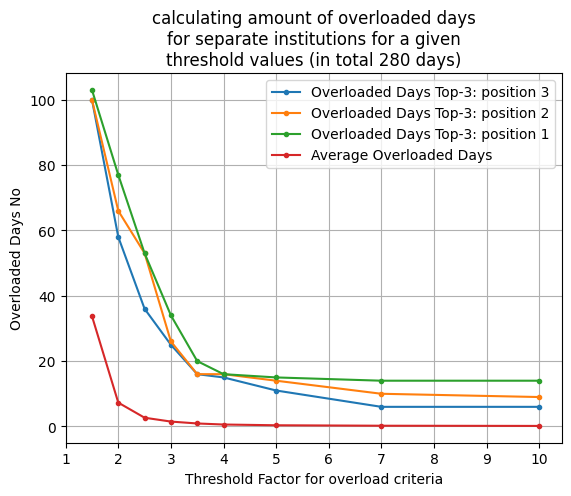

In [128]:
for i in [1,2,3]:
    plt.plot(top_3[:,0], top_3[:,i], label=f'Overloaded Days Top-3: position {4-i}', marker='.')

plt.plot(top_3[:,0], top_3[:,4], label='Average Overloaded Days', marker='.')
plt.title('calculating amount of overloaded days\n' +
          'for separate institutions for a given\n' + 
          'threshold values (in total 280 days)')
plt.xlabel('Threshold Factor for overload criteria')
plt.ylabel('Overloaded Days No')
plt.legend()
plt.xticks(range(1,11))
plt.grid()
plt.show()

In [129]:
for csv_file in [el for el in os.listdir(os.path.join(proj_root,'data','institutions','agg_1_day')) if el.endswith('.csv')]:

    tmp_df = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', csv_file))[flds_selection]

    tmp_df['is_overloaded'] = tmp_df[thres_fld] > tmp_df[thres_fld].mean() * thres_factor

    if tmp_df['is_overloaded'].sum() > 30:
        print(f"File {csv_file} has {tmp_df['is_overloaded'].sum()} overloaded days")

File 217.csv has 53 overloaded days
File 246.csv has 36 overloaded days
File 264.csv has 53 overloaded days


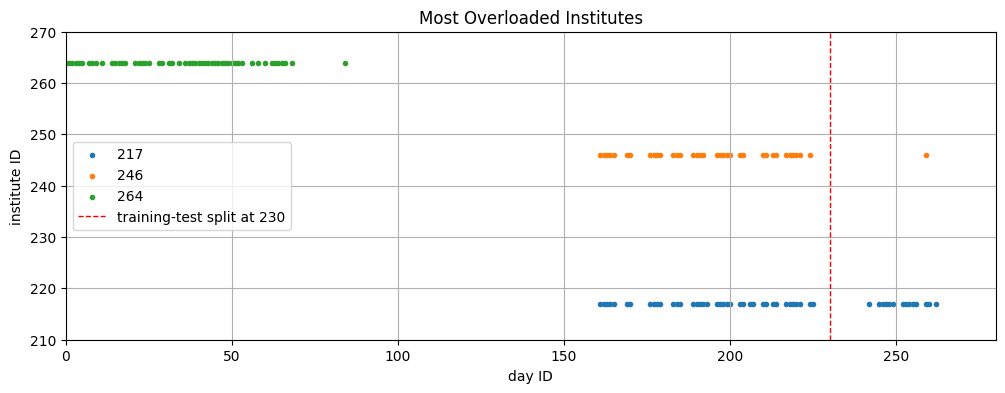

In [150]:
tmp_df_217 = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', '217.csv'))[flds_selection]
tmp_df_217['is_overloaded'] = tmp_df_217[thres_fld] > tmp_df_217[thres_fld].mean() * thres_factor

tmp_df_246 = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', '246.csv'))[flds_selection]
tmp_df_246['is_overloaded'] = tmp_df_246[thres_fld] > tmp_df_246[thres_fld].mean() * thres_factor

tmp_df_264 = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', '264.csv'))[flds_selection]
tmp_df_264['is_overloaded'] = tmp_df_264[thres_fld] > tmp_df_264[thres_fld].mean() * thres_factor

plt.figure(figsize=(12, 4))

plt.scatter(tmp_df_217.id_time, 217*tmp_df_217['is_overloaded'], label='217', marker='.')
plt.scatter(tmp_df_246.id_time, 246*tmp_df_246['is_overloaded'], label='246', marker='.')
plt.scatter(tmp_df_264.id_time, 264*tmp_df_264['is_overloaded'], label='264', marker='.')
plt.axvline(230, color='red', linestyle='--', linewidth=1, label='training-test split at 230')
plt.ylim(210, 270)
plt.xlim(0,280)  #(150, 280)
plt.xlabel('day ID')
plt.ylabel('institute ID')
plt.title('Most Overloaded Institutes')
plt.legend(loc='center left')
plt.grid()
plt.show()

## поехали собирать весь датасет

In [130]:
for csv_file in [el for el in os.listdir(os.path.join(proj_root,'data','institutions','agg_1_day')) if el.endswith('.csv')]:

    tmp_df = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', csv_file))[flds_selection]

    tmp_df['is_overloaded'] = tmp_df[thres_fld] > tmp_df[thres_fld].mean() * thres_factor

    tmp_df['id_inst'] = [int(csv_file.split('.')[0])] * len(tmp_df)

    